<a href="https://colab.research.google.com/github/michellyaanjos/telecom-x/blob/main/TelecomX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# Importação de Bibliotecas
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#📌 Extração

## ✅ Extração dos Dados

In [3]:
# Captura URL do JSON
url = 'https://raw.githubusercontent.com/michellyaanjos/telecom-x/refs/heads/main/data/TelecomX_Data.json'

# Armazena no objeto 'response'
response = requests.get(url)

# Converte o conteúdo em dicionário
data = response.json()
data

[{'customerID': '0002-ORFBO',
  'Churn': 'No',
  'customer': {'gender': 'Female',
   'SeniorCitizen': 0,
   'Partner': 'Yes',
   'Dependents': 'Yes',
   'tenure': 9},
  'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'},
  'internet': {'InternetService': 'DSL',
   'OnlineSecurity': 'No',
   'OnlineBackup': 'Yes',
   'DeviceProtection': 'No',
   'TechSupport': 'Yes',
   'StreamingTV': 'Yes',
   'StreamingMovies': 'No'},
  'account': {'Contract': 'One year',
   'PaperlessBilling': 'Yes',
   'PaymentMethod': 'Mailed check',
   'Charges': {'Monthly': 65.6, 'Total': '593.3'}}},
 {'customerID': '0003-MKNFE',
  'Churn': 'No',
  'customer': {'gender': 'Male',
   'SeniorCitizen': 0,
   'Partner': 'No',
   'Dependents': 'No',
   'tenure': 9},
  'phone': {'PhoneService': 'Yes', 'MultipleLines': 'Yes'},
  'internet': {'InternetService': 'DSL',
   'OnlineSecurity': 'No',
   'OnlineBackup': 'No',
   'DeviceProtection': 'No',
   'TechSupport': 'No',
   'StreamingTV': 'No',
   'StreamingMovies': 

In [4]:
# Converte em DataFrame
df = pd.DataFrame(data)

# Exibe as 5 primeiras linhas do DataFrame
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [5]:
# Transforma estruturas aninhadas em colunas
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


🔍 **Análise da Estrutura dos Dados**
Os dados são organizados em um formato hierárquico (dicionário dentro de dicionário), contendo as seguintes informações:

1. **Identificação do Cliente**  
   - `'customerID'`: Identificador único do cliente.  
   - `'Churn'`: Indica se o cliente cancelou o serviço (`Yes` ou `No`).  

2. **Informações do Cliente** (`'customer'`)  
   - `'gender'`: Gênero do cliente (`Male` ou `Female`).  
   - `'SeniorCitizen'`: Indica se o cliente é idoso (0 = Não, 1 = Sim).  
   - `'Partner'`: Se o cliente tem um parceiro(a).  
   - `'Dependents'`: Se o cliente tem dependentes.  
   - `'tenure'`: Tempo de permanência como cliente (em meses).  

3. **Serviços de Telefonia** (`'phone'`)  
   - `'PhoneService'`: Indica se o cliente possui serviço de telefone (`Yes` ou `No`).  
   - `'MultipleLines'`: Se possui múltiplas linhas telefônicas.  

4. **Serviços de Internet** (`'internet'`)  
   - Tipo de serviço de internet contratado (`DSL`, `Fiber optic`, `No`).  
   - Serviços adicionais (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`).  

5. **Informações da Conta** (`'account'`)  
   - `'Contract'`: Tipo de contrato (`Month-to-month`, `One year`, `Two year`).  
   - `'PaperlessBilling'`: Se o cliente recebe faturas eletrônicas.  
   - `'PaymentMethod'`: Método de pagamento (`Bank transfer`, `Credit card`, `Electronic check`, `Mailed check`).  
   - `'Charges'`:  
     - `'Monthly'`: Valor mensal cobrado.  
     - `'Total'`: Valor total pago pelo cliente.  

#🔧 Transformação

## ✅ Conhecendo o Dataset

In [6]:
# Conhecendo colunas e os tipos de dados em cada uma delas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

## ✅ Verificando Inconsistências nos Dados

1. Verificando valores únicos

In [7]:
# Percorre todas as colunas do DataFrame
for col in df.columns:

  # Imprime o nome da coluna e seus valores únicos
  print(f'{col}: {df[col].unique()}')

  # Verifica se a coluna tem menos de 50 valores únicos
  if df[col].nunique() < 50:

    # Imprime novamente os valores únicos (lista completa)
    print(df[col].unique())

    # Imprime uma linha separadora para organizar a saída
    print('-' * 50)

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn: ['No' 'Yes' '']
['No' 'Yes' '']
--------------------------------------------------
customer.gender: ['Female' 'Male']
['Female' 'Male']
--------------------------------------------------
customer.SeniorCitizen: [0 1]
[0 1]
--------------------------------------------------
customer.Partner: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
customer.Dependents: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
customer.tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService: ['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
phone.MultipleLines: ['No' 'Yes' 'No phone service']
['No' 'Yes' 'No phone service']
------

2. Valores duplicados

In [8]:
# Imprime na tela a quantidade de linhas duplicadas no DataFrame
print("Numero de duplicados", df.duplicated().sum())

Numero de duplicados 0


3. Valores nulos

In [9]:
# Imprime a quantidade de valores nulos (NaN) existentes em cada coluna do DataFrame
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


4. Vazios ou em branco

In [10]:
# Conta quantos valores vazios (strings em branco ou só com espaços)
# existem em cada coluna do DataFrame
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


## ✅ Tratando as Inconsistências

**TRANSFORMAÇÕES**

1. Alterando a coluna "account.Charges.Total" para Float

In [11]:
# Converte a coluna 'account.Charges.Total' para formato numérico
# e transforma valores inválidos em NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

2. Removendo valores vazios da coluna "Churn"

In [12]:
# Remove as linhas em que a coluna 'Churn' está vazia ou contém apenas espaços em branco
df = df[df['Churn'].str.strip() != '']

# Imprime a quantidade de linhas restantes após a remoção das linhas vazias em 'Churn'
print("Número de linhas depois de eliminar as vazias em 'Churn':", len(df))

Número de linhas depois de eliminar as vazias em 'Churn': 7043


3. Verificação de vazias, em branco e nulos

In [13]:
# Conta, em cada coluna do DataFrame, quantos valores são strings vazias
# ou contêm apenas espaços em branco
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [14]:
# Imprime a quantidade de valores nulos (NaN) existentes em cada coluna do DataFrame
print("Número de Nulos \n", df.isnull().sum())

Número de Nulos 
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


4. Removendo valores nulos de "account.Charges.Total"

In [15]:
# Remove as linhas que possuem valor nulo (NaN) na coluna 'account.Charges.Total'
df = df.dropna(subset=['account.Charges.Total'])

In [16]:
# Exibe a quantidade de valores nulos (NaN) existentes em cada coluna do DataFrame
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


## ✅ Coluna de Contas Diárias

In [17]:
# Cria a coluna 'contas_diarias' calculando o valor diário a partir da cobrança mensal
df['contas_diarias'] = df['account.Charges.Monthly'] / 30
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


## ✅ Padronização e Transformação de Dados

In [18]:
# Dicionário que mapeia os nomes antigos das colunas para nomes mais curtos e em português
colunas = {
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tem +60',
    'customer.Partner': 'possui_parceiro',
    'customer.Dependents': 'possui_dependentes',
    'customer.tenure': 'tempo_contrato',
    'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguranca_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo',
    'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'
}

# Renomeia as colunas do DataFrame usando o dicionário definido acima
df = df.rename(columns= colunas)
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [19]:
# Padroniza e traduz os valores das colunas para português
df['Churn'] = df['Churn'].replace({
    'No': 'Não',
    'Yes': 'Sim'
})
df['genero'] = df['genero'].replace({
    'Female': 'Feminino',
    'Male': 'Masculino'
})
df['possui_parceiro'] = df['possui_parceiro'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})
df['possui_dependentes'] = df['possui_dependentes'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})
df['servico_telefone'] = df['servico_telefone'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})
df['multiplas_linhas'] = df['multiplas_linhas'].replace({
    'No': 'Não',
    'Yes': 'Sim',
    'No phone service': 'Sem serviço de telefone'
})
df['tipo_internet'] = df['tipo_internet'].replace({
    'No': 'Não'
})

df.head()

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [20]:
# Lista com as colunas que terão seus valores traduzidos/padronizados
columns_to_translate = [
    'seguranca_online',
    'backup_online',
    'protecao_dispositivo',
    'suporte_tecnico',
    'streaming_tv',
    'streaming_filmes'
]

# Dicionário com o mapeamento de tradução dos valores categóricos
mapping = {'No': 'Não',
           'Yes': 'Sim',
           'No internet service': 'Sem serviço de internet'
}

# Percorre cada coluna da lista e aplica a tradução dos valores usando o mapeamento definido
for col in columns_to_translate:
    df[col] = df[col].replace(mapping)

In [21]:
# Traduz e padroniza os valores da coluna 'tipo_contrato' para português
df['tipo_contrato'] = df['tipo_contrato'].replace({
    'One year': 'Anual',
    'Month-to-month': 'Mensal',
    'Two year': 'Bienal'
})

In [22]:
# Traduz e padroniza os valores da coluna 'fatura_digital' para português
df['fatura_digital'] = df['fatura_digital'].replace({
    'Yes': 'Sim',
    'No': 'Não'
})

In [23]:
# Traduz e padroniza os valores da coluna 'metodo_pagamento' para português
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'
})

In [24]:
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.60,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.90,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,0,Não,Não,13,Sim,Não,DSL,...,Não,Sim,Não,Não,Anual,Não,Cheque enviado,55.15,742.90,1.838333
7263,9992-RRAMN,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Fiber optic,...,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.836667
7264,9992-UJOEL,Não,Masculino,0,Não,Não,2,Sim,Não,DSL,...,Não,Não,Não,Não,Mensal,Sim,Cheque enviado,50.30,92.75,1.676667
7265,9993-LHIEB,Não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,...,Sim,Sim,Não,Sim,Bienal,Não,Cheque enviado,67.85,4627.65,2.261667


#📊 Carga e análise

## ✅ Análise Descritiva

In [25]:
# Gera estatísticas descritivas das colunas numéricas do DataFrame (média, mediana, mínimo, máximo, etc.)
df.describe()

,tem +60,tempo_contrato,valor_mensal,total_cobrado,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


## ✅ Distribuição de Evasão

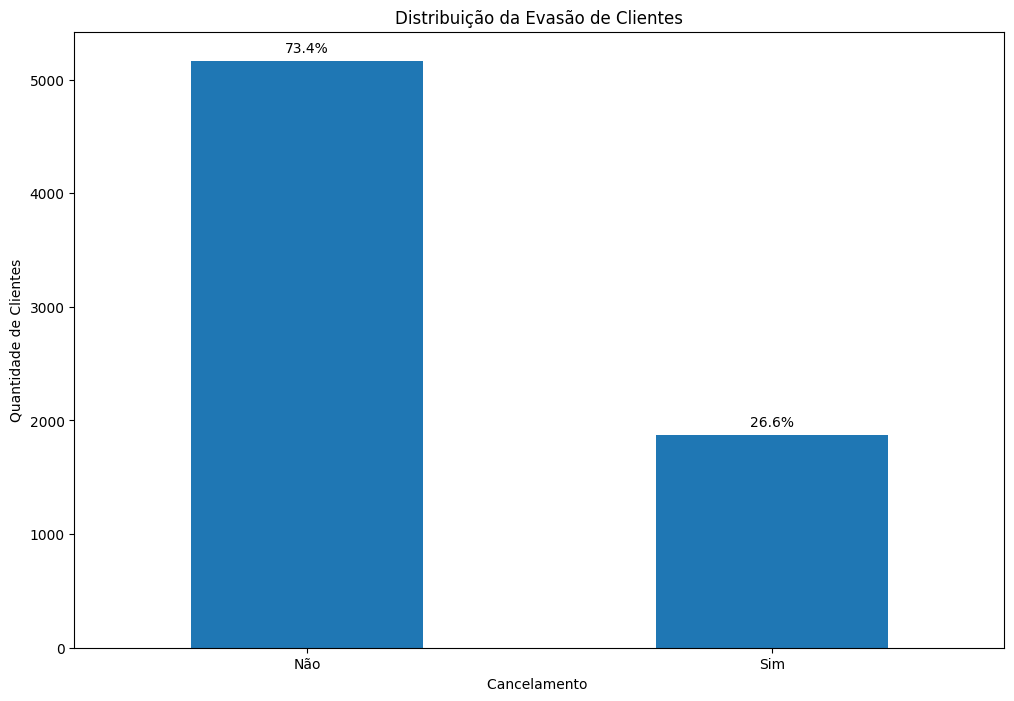

In [26]:
# Define o tamanho da figura do gráfico
plt.figure(figsize=(12, 8))

# Conta a quantidade de clientes por categoria de Churn (Sim / Não)
churn_counts = df['Churn'].value_counts()

# Calcula a porcentagem de cada categoria em relação ao total de clientes
churn_percentages = (churn_counts / len(df)) * 100

# Cria o gráfico de barras com a quantidade de clientes
ax = churn_counts.plot(kind='bar')

# Define o título e os rótulos dos eixos
plt.title('Distribuição da Evasão de Clientes')
plt.xlabel('Cancelamento ')
plt.ylabel('Quantidade de Clientes')

# Mantém os rótulos do eixo X na horizontal
plt.xticks(rotation=0)

# Adiciona o valor percentual acima de cada barra do gráfico
for i, percentage in enumerate(churn_percentages):
    ax.text(i, churn_counts.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')

# Exibe o gráfico
plt.show()

## ✅ Contagem de Evasão por Variáveis Categóricas

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7032 non-null   object 
 1   Churn                 7032 non-null   object 
 2   genero                7032 non-null   object 
 3   tem +60               7032 non-null   int64  
 4   possui_parceiro       7032 non-null   object 
 5   possui_dependentes    7032 non-null   object 
 6   tempo_contrato        7032 non-null   int64  
 7   servico_telefone      7032 non-null   object 
 8   multiplas_linhas      7032 non-null   object 
 9   tipo_internet         7032 non-null   object 
 10  seguranca_online      7032 non-null   object 
 11  backup_online         7032 non-null   object 
 12  protecao_dispositivo  7032 non-null   object 
 13  suporte_tecnico       7032 non-null   object 
 14  streaming_tv          7032 non-null   object 
 15  streaming_filmes      7032

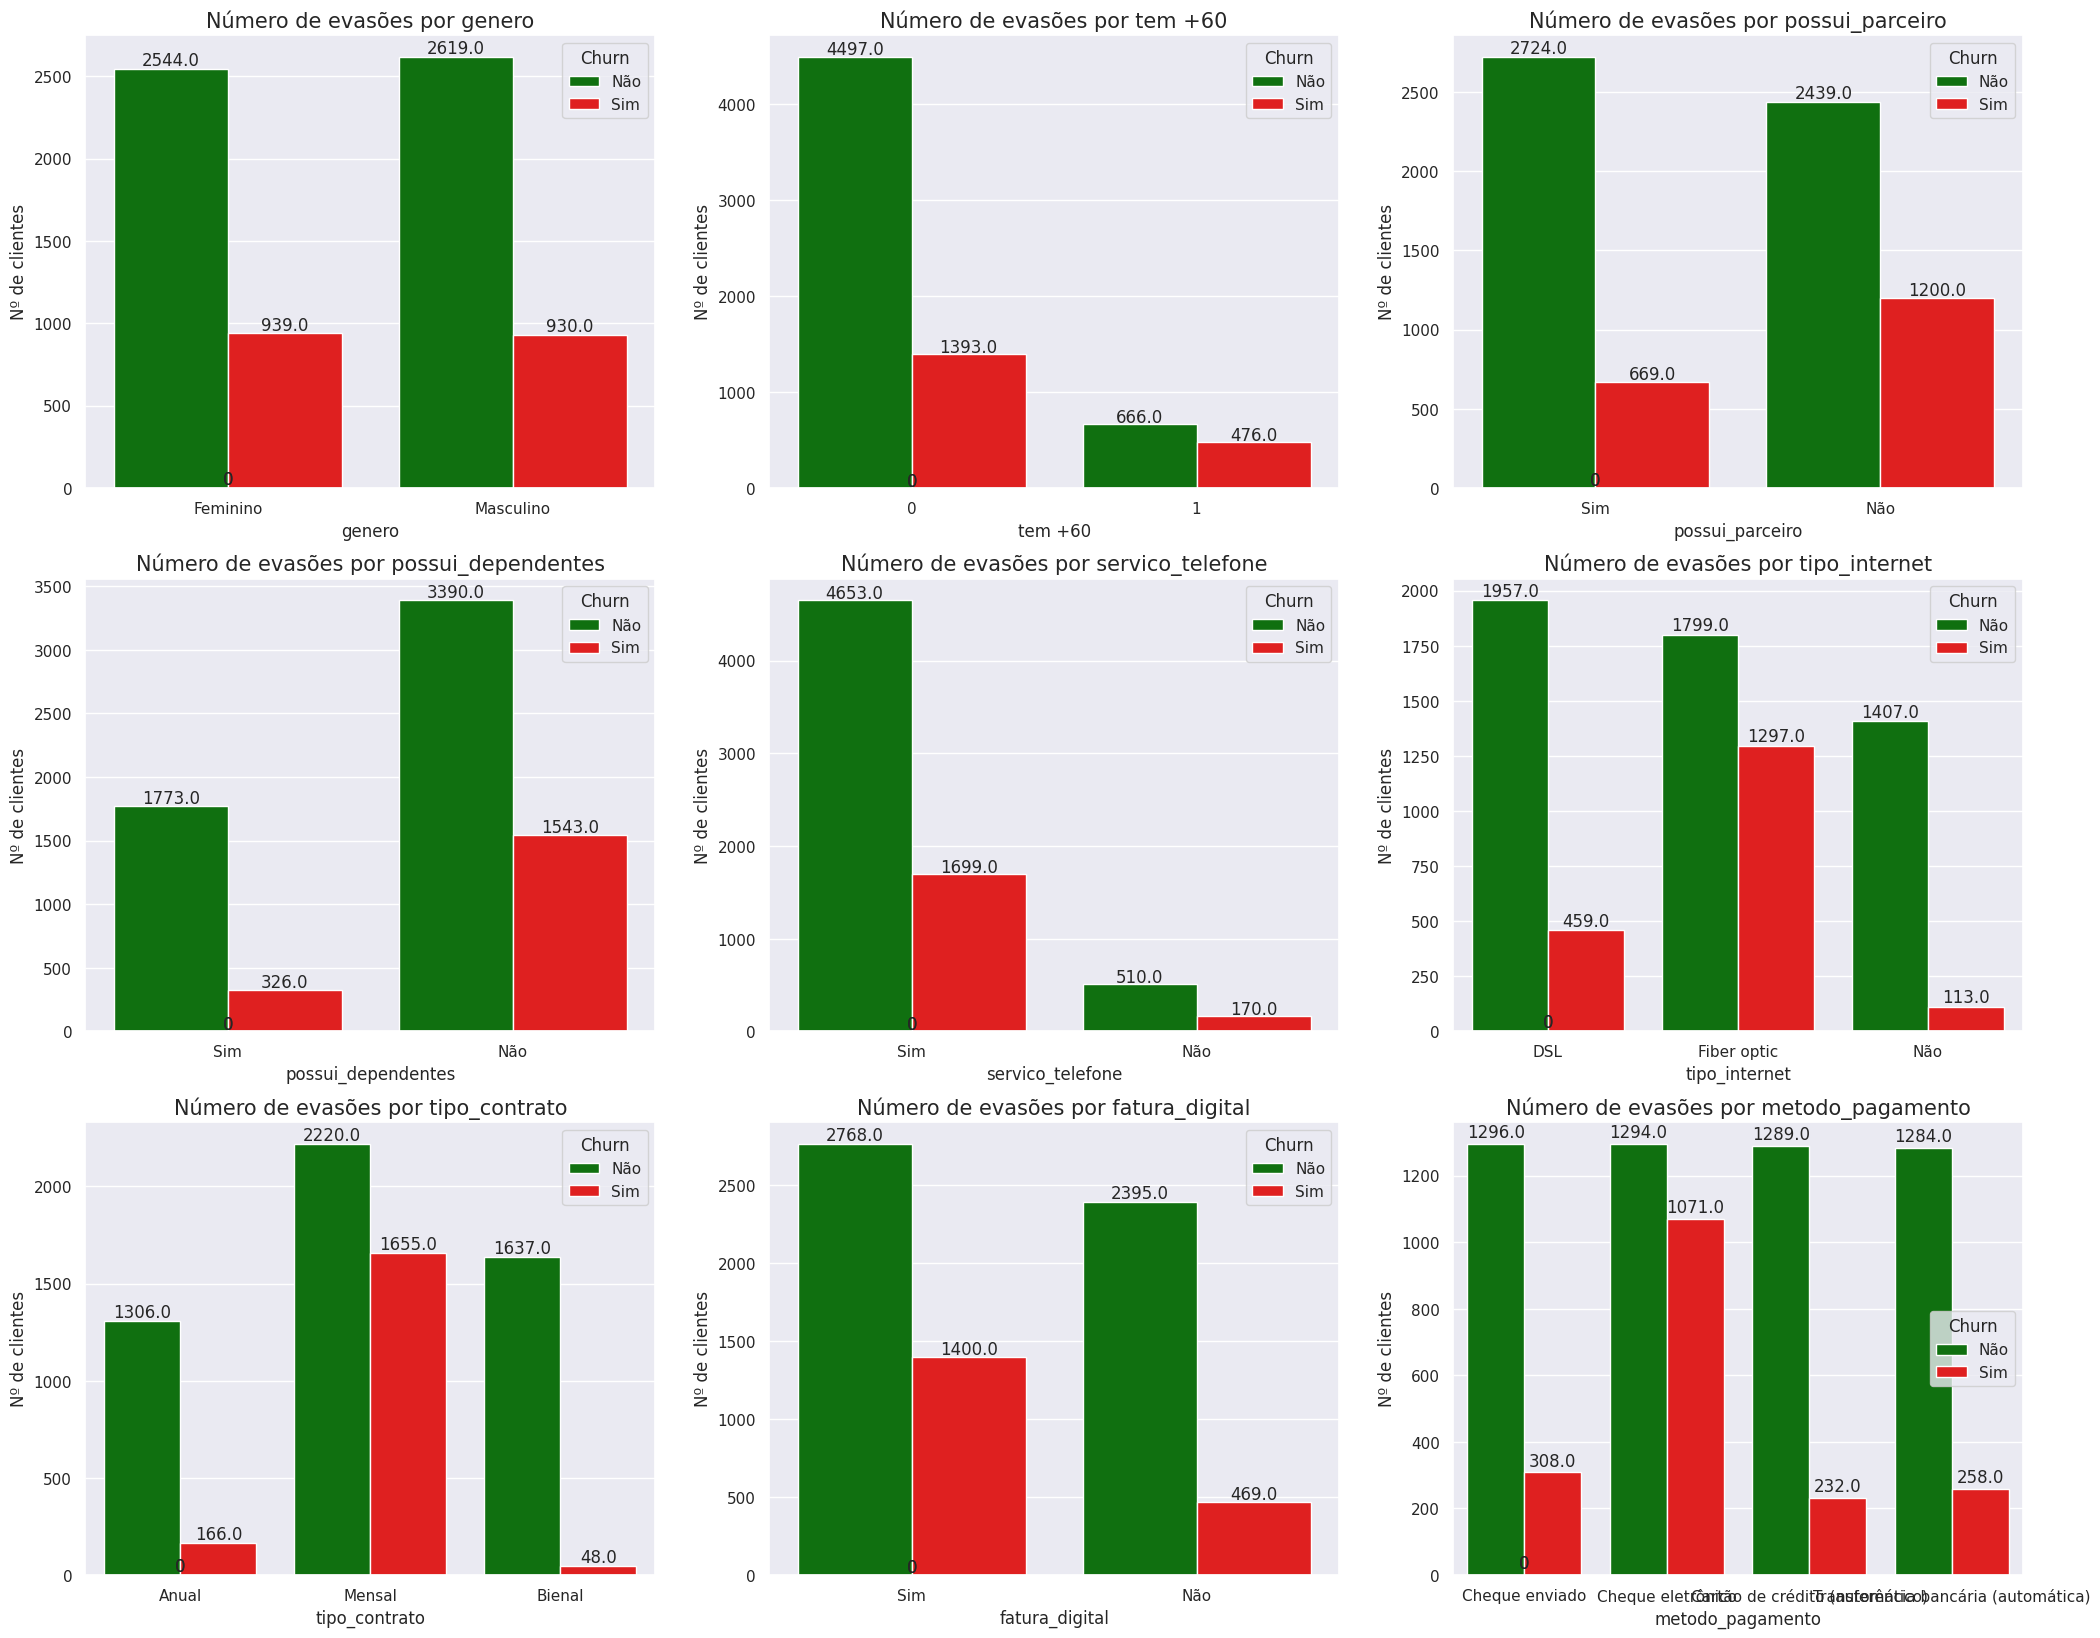

In [28]:
# Lista com as variáveis categóricas que serão analisadas em relação ao Churn
variaveis_categoricas = [
    'genero', 'tem +60', 'possui_parceiro',
    'possui_dependentes', 'servico_telefone',
    'tipo_internet', 'tipo_contrato',
    'fatura_digital', 'metodo_pagamento'
]

# Cria uma lista enumerada (índice + nome da variável) para usar no loop
lista_variaveis_categoricas = list(enumerate(variaveis_categoricas))

# Define o tamanho padrão das figuras do seaborn
sns.set(rc = {'figure.figsize':(25,20)})

# Loop para criar um gráfico para cada variável categórica
for i in lista_variaveis_categoricas:

    # Define a posição do subplot (grade 3x3)
    plt.subplot(3, 3,  i[0]+1)

    # Cria um gráfico de contagem separado por Churn
    ax = sns.countplot(data = df,
                    x = i[1],
                    hue = 'Churn',
                    palette = {'Não': 'green', 'Sim': 'red'},
    )

    # Define o título e rótulos do gráfico
    ax.set_title(f'Número de evasões por {i[1]}', fontsize = 15)
    ax.set_ylabel('Nº de clientes', fontsize = 12)
    ax.set_xlabel(i[1], fontsize = 12)

    # Adiciona rótulos com a quantidade de clientes acima de cada barra
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x()+p.get_width()/2.,
        height + 20,
        '{:1}'.format((height)),
        ha='center',
        size = 12)

plt.show()

## ✅ Contagem de Evasão por Variáveis Numéricas


In [29]:
# Cria um histograma para analisar a distribuição do tempo de contrato,
# separando os clientes por Churn (Sim/Não) e exibindo os valores nas barras
px.histogram(df, x = 'tempo_contrato', text_auto = True, color = 'Churn', barmode = 'group')

#📄Relatorio Final

## 1. Introdução

A análise de evasão de clientes (churn) da Telecom X tem como objetivo compreender os principais fatores que levam os clientes a cancelarem seus serviços, utilizando dados para identificar padrões de comportamento e possíveis causas da saída. Por meio da coleta, tratamento e análise dos dados com Python, a empresa busca gerar insights estratégicos que apoiem a equipe de Data Science no desenvolvimento de modelos preditivos e ações eficazes de retenção, reduzindo perdas financeiras e melhorando a tomada de decisão.

## 2. Limpeza e Tratamento de Dados

Os dados foram importados a partir da URL de um arquivo JSON e convertidos em um DataFrame, seguido pela transformação das estruturas aninhadas em colunas. Foi realizada então uma verificação de valores únicos, duplicados, nulos, vazios ou em branco, permitindo identificar e corrigir inconsistências. O tratamento incluiu a conversão da coluna `'account.Charges.Total'`, originalmente em formato textual, para numérico, a remoção de valores vazios da coluna `'Churn'` e a exclusão de registros com valores nulos em `'account.Charges.Total'`. Além disso, foi criada uma nova coluna representando o valor diário da conta, e, por fim, os nomes e valores das colunas foram padronizados e traduzidos para o português, garantindo maior clareza e consistência para as análises posteriores.

## 3. Análise Exploratória de Dados


- A análise do gráfico de 'Distribuição da Evasão de Clientes' revela que **73,5%** dos clientes **não evadiram**, enquanto **26,5%** dos clientes **evadiram**. Isso indica que a maioria dos clientes permanece com o serviço, mas uma parcela significativa está cancelando. A taxa de evasão de **26,5%** é um ponto de atenção importante para a empresa.

- A análise das variáveis categóricas em relação ao Churn indica que a maior taxa de evasão está concentrada em clientes com **contrato mensal**, usuários de **fibra óptica**, aqueles que utilizam **cheque eletrônico** como forma de pagamento, clientes que optam pela **fatura digital** e os que **não possuem parceiro ou dependentes**. O gênero não apresenta influência relevante na evasão, enquanto clientes **idosos** demonstram apenas uma leve tendência maior ao Churn. Já o serviço de telefone, isoladamente, não se mostra um fator determinante.

- Com base na análise das variáveis numéricas, focando no tempo de permanência do cliente, a principal observação é que clientes com **menor tempo de contrato** são significativamente mais propensos a evadir. A taxa de Churn é visivelmente maior nos primeiros meses de contrato e tende a diminuir à medida que o tempo de permanência aumenta. Isso sugere que a fase inicial do relacionamento com o cliente é crítica para a retenção.

## 4. Conclusões e Insights

A análise exploratória evidencia que, embora a maioria dos clientes da Telecom X permaneça ativa, a taxa de evasão de **26,5%** é relevante e representa um impacto significativo para o negócio. Os dados mostram que o Churn não ocorre de forma aleatória, estando fortemente associado a características contratuais, comportamentais e ao estágio do relacionamento do cliente com a empresa. Clientes com contrato mensal, menor tempo de permanência e determinados padrões de pagamento e consumo apresentam maior propensão ao cancelamento, indicando fragilidade na retenção inicial. Além disso, fatores como ausência de parceiro ou dependentes sugerem menor vínculo com o serviço. Esses achados fornecem uma base sólida para a criação de estratégias de retenção direcionadas e para o desenvolvimento de modelos preditivos capazes de identificar clientes em risco de evasão de forma antecipada.

## 5. Recomendações

Com base nos insights obtidos, recomenda-se priorizar ações focadas nos **primeiros meses de contrato**, período crítico para a retenção, por meio de programas de onboarding (processo de acolhimento e orientação inicial do cliente), comunicação proativa e acompanhamento personalizado. Estratégias de incentivo à migração de contratos mensais para planos de maior duração podem contribuir para a redução do Churn, assim como a revisão da experiência dos clientes que utilizam fibra óptica, garantindo qualidade e estabilidade do serviço. Também é indicado avaliar alternativas ao cheque eletrônico e à fatura digital, oferecendo benefícios ou facilidades para clientes que optem por métodos de pagamento associados a menor evasão. Por fim, os resultados desta análise devem ser utilizados como base para a construção de modelos preditivos de Churn, permitindo intervenções antecipadas e decisões estratégicas mais assertivas.